<div style="background:linear-gradient(135deg,#172554 0%,#1e40af 55%,#3b82f6 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bfdbfe;font-weight:700;text-transform:uppercase">Chapter 70 · Estimation &amp; Confidence Intervals</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Confidence Intervals for a Mean 📏</div>
  <div style="font-size:15px;color:#eff6ff;max-width:740px;line-height:1.6">When sigma is known we use the z-interval; when it is unknown (almost always) we estimate it with s and use the t-distribution. We build both, check coverage, then put a 95% interval on the mean delivery time from a real logistics spreadsheet.</div>
  <div style="margin-top:16px;font-size:13px;color:#bfdbfe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
BLUE="#2563eb"; DEEP="#1d4ed8"; LIGHT="#60a5fa"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(70)

<div style="background:#eef2ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">BEAT 1 · THE z-INTERVAL (sigma known)</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The textbook starting point</div>
<div style="color:#4a5578;margin-top:6px">If the population sigma were known, a 95% CI for the mean is x-bar +/- 1.96 * sigma/sqrt(n). This is clean but unrealistic: we almost never know sigma.</div>
</div>

In [2]:
sigma_true = 12.0; n = 45
sample = rng.normal(100, sigma_true, n)
xbar = sample.mean(); se = sigma_true/np.sqrt(n); z = stats.norm.ppf(0.975)
print(f"x-bar = {xbar:.2f}, sigma known = {sigma_true}, SE = {se:.3f}")
print(f"95% z-interval: [{xbar-z*se:.2f}, {xbar+z*se:.2f}]  (z* = {z:.3f})")

x-bar = 101.61, sigma known = 12.0, SE = 1.789
95% z-interval: [98.11, 105.12]  (z* = 1.960)


Clean, but it assumes we know &#963;. In practice we only have the <em>sample</em> standard deviation s, and plugging s into the z-interval understates the uncertainty for small samples. The fix is the t-distribution.

<div style="background:#eef2ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">BEAT 2 · THE t-INTERVAL (sigma unknown)</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Estimate sigma with s, widen with t</div>
<div style="color:#4a5578;margin-top:6px">Replace sigma by the sample sd s, and replace z by t*, the critical value of Student's t with n-1 degrees of freedom. The t has heavier tails, so t* > z, making the interval a little wider, the honest price of estimating sigma.</div>
</div>

In [3]:
s = sample.std(ddof=1)
se_t = s/np.sqrt(n)
tcrit = stats.t.ppf(0.975, df=n-1)
print(f"sample sd s = {s:.2f}, SE = s/sqrt(n) = {se_t:.3f}")
print(f"t* (df={n-1}) = {tcrit:.3f}  vs  z* = {z:.3f}")
print(f"95% t-interval: [{xbar-tcrit*se_t:.2f}, {xbar+tcrit*se_t:.2f}]")
# scipy one-liner agrees
ci = stats.t.interval(0.95, df=n-1, loc=xbar, scale=se_t)
print(f"scipy stats.t.interval: [{ci[0]:.2f}, {ci[1]:.2f}]")

sample sd s = 10.90, SE = s/sqrt(n) = 1.624
t* (df=44) = 2.015  vs  z* = 1.960
95% t-interval: [98.34, 104.89]
scipy stats.t.interval: [98.34, 104.89]


In [4]:
dfs = [2,5,10,30,100,1000]
print(f"{'df':>5} | {'t*':>7} | {'z*':>6}")
for d in dfs: print(f"{d:>5} | {stats.t.ppf(0.975,d):>7.3f} | {z:>6.3f}")
print("t* shrinks toward z* as df grows: by df=1000 they are nearly identical")

   df |      t* |     z*
    2 |   4.303 |  1.960
    5 |   2.571 |  1.960
   10 |   2.228 |  1.960
   30 |   2.042 |  1.960
  100 |   1.984 |  1.960
 1000 |   1.962 |  1.960
t* shrinks toward z* as df grows: by df=1000 they are nearly identical


The t critical value exceeds 1.96 for small samples (2.776 at df=4) and converges to z as the sample grows. By n &#8776; 30&#8211;60 the difference is tiny. Using the t-interval keeps small-sample conclusions honest; using z when &#963; is unknown overstates precision.

<div style="background:#eef2ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">BEAT 3 · COVERAGE & CONDITIONS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Does the 95% interval really cover 95%?</div>
<div style="color:#4a5578;margin-top:6px">A CI is only valid if its assumptions hold: the data is roughly normal OR n is large enough for the CLT. We check coverage by simulation, and see it hold for a moderately skewed population once n is reasonable.</div>
</div>

In [5]:
pop = rng.gamma(4, 6, 1_000_000)        # right-skewed population
MU = pop.mean()
def covers(n):
    s = rng.choice(pop, n, replace=False); xb=s.mean(); se=s.std(ddof=1)/np.sqrt(n)
    lo,hi = stats.t.interval(0.95, n-1, xb, se); return lo<=MU<=hi
for n in [10, 30, 100]:
    cov = np.mean([covers(n) for _ in range(4000)])
    print(f"n={n:>4}: t-interval coverage = {cov*100:.1f}%  (target 95%)")
print("\nskewed data + tiny n undercovers; by n=30+ the CLT makes the t-interval reliable")

n=  10: t-interval coverage = 93.5%  (target 95%)


n=  30: t-interval coverage = 94.0%  (target 95%)


n= 100: t-interval coverage = 94.7%  (target 95%)

skewed data + tiny n undercovers; by n=30+ the CLT makes the t-interval reliable


With a skewed population and n = 10 the interval under-covers (the CLT has not kicked in), but by <strong>n = 30</strong> coverage is close to 95% and by n = 100 it is on target. The rule of thumb: the t-interval is trustworthy when the data is roughly symmetric, or when n is at least ~30.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">REAL-WORLD EXAMPLE · DELIVERY TIMES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A 95% interval for the mean delivery time</div>
<div style="color:#4a5578;margin-top:6px"></div>
</div>

A logistics team exports <strong>180 completed shipments</strong> (`ch70_delivery_times.xlsx`) and wants a confidence interval for the average door-to-door delivery time. Sigma is unknown, so we use the t-interval, after checking the shape.

In [6]:
try:    ship = pd.read_excel("../../data/ch70_delivery_times.xlsx", sheet_name="Shipments")
except FileNotFoundError: ship = pd.read_excel(BASE+"ch70_delivery_times.xlsx", sheet_name="Shipments")
print("loaded:", ship.shape)
h = ship["delivery_hours"]
n = len(h); xbar = h.mean(); s = h.std(ddof=1); se = s/np.sqrt(n)
tcrit = stats.t.ppf(0.975, n-1)
lo, hi = stats.t.interval(0.95, n-1, xbar, se)
print(f"n = {n} shipments")
print(f"mean delivery time = {xbar:.2f} h, sd = {s:.2f}, SE = {se:.3f}")
print(f"t* (df={n-1}) = {tcrit:.3f}")
print(f"95% t-interval for the MEAN: [{lo:.2f} h, {hi:.2f} h]")

loaded: (180, 6)
n = 180 shipments
mean delivery time = 35.85 h, sd = 10.11, SE = 0.753
t* (df=179) = 1.973
95% t-interval for the MEAN: [34.37 h, 37.34 h]


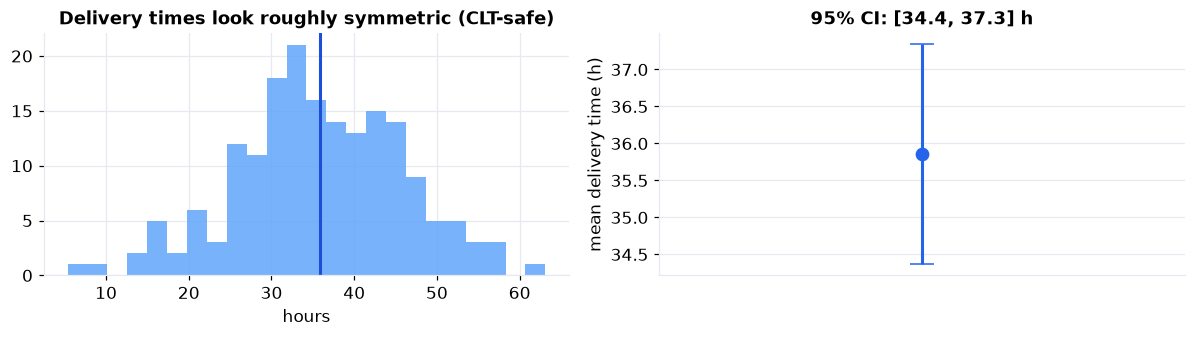

In [7]:
fig,ax=plt.subplots(1,2,figsize=(11,3.2))
ax[0].hist(h, bins=24, color=LIGHT, alpha=0.85); ax[0].axvline(xbar,color=DEEP,lw=2)
ax[0].set_title("Delivery times look roughly symmetric (CLT-safe)"); ax[0].set_xlabel("hours")
ax[1].errorbar([0],[xbar],yerr=[[xbar-lo],[hi-xbar]],fmt="o",color=BLUE,capsize=8,lw=2,ms=8)
ax[1].set_xlim(-1,1); ax[1].set_xticks([]); ax[1].set_ylabel("mean delivery time (h)")
ax[1].set_title(f"95% CI: [{lo:.1f}, {hi:.1f}] h")
plt.tight_layout(); plt.show()

The average delivery time is about <strong>35.9 hours</strong>, with a 95% interval of roughly <strong>34.4 to 37.3 hours</strong>. The histogram is reasonably symmetric and n = 180 is large, so the conditions hold and the interval is trustworthy. The team can promise "about a day and a half on average" with quantified confidence, not a bare point.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ CI for a mean</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">When sigma is known, x-bar +/- z*(sigma/sqrt(n)); when it is unknown (the real case), x-bar +/- t*(s/sqrt(n)) with df=n-1. The t-interval is a touch wider because we estimated sigma. It is valid when the data is roughly normal or n is large (~30+). On real delivery data the mean is ~35.9 h with a 95% interval of about 34.4 to 37.3 h.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>